In [1]:
import argparse
from collections import defaultdict, deque

import cv2
import numpy as np
from ultralytics import YOLO

import supervision as sv

In [2]:
frame_generator = sv.get_video_frames_generator(source_path='videos/traffic_3rd.mp4')
frame_iterator = iter(frame_generator)
frame = next(frame_iterator)

In [3]:
SOURCE = np.array([
    [ 810,  566],
    [ 1788,  566],
    [2800,  1480],
    [0,  1480]
])

TARGET_WIDTH = 12
TARGET_HEIGHT = 50

TARGET = np.array([
    [0, 0],
    [TARGET_WIDTH - 1, 0],
    [TARGET_WIDTH - 1, TARGET_HEIGHT - 1],
    [0, TARGET_HEIGHT - 1],
])

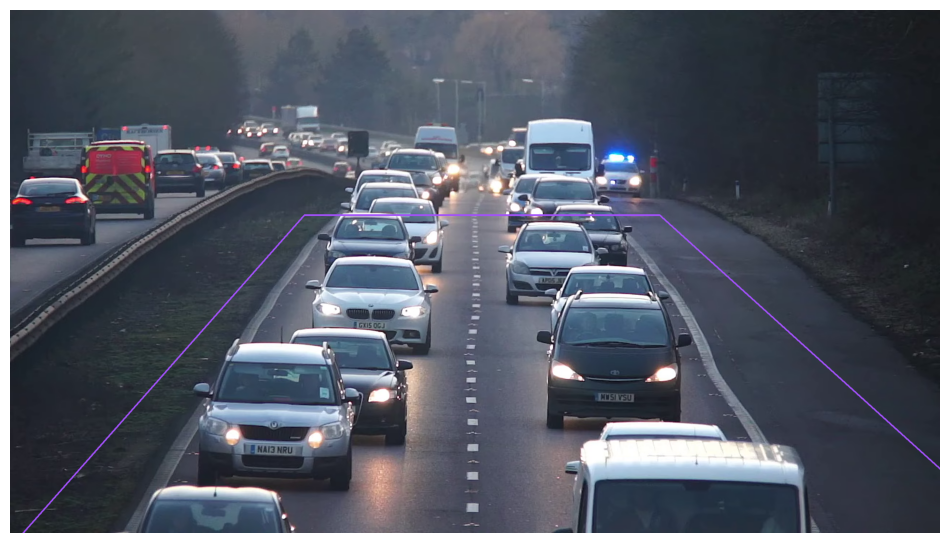

In [4]:
annotated_frame = frame.copy()
annotated_frame = sv.draw_polygon(scene=annotated_frame, polygon=SOURCE, thickness=4)
sv.plot_image(annotated_frame)

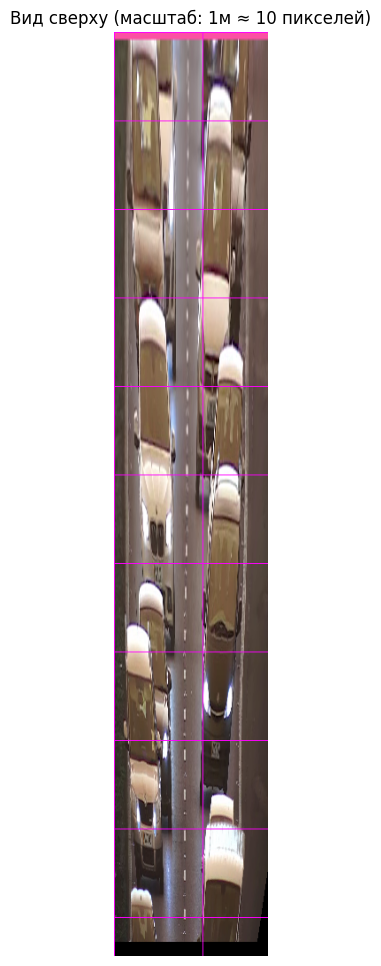

In [15]:
import matplotlib.pyplot as plt

length = 120
width = 20

DEST = np.array([
    [0, 0],
    [width, 0],
    [width, length],
    [0, length]
], dtype="float32")

# Масштабируем, чтобы пиксели ≈ сантиметры (1 м = 10 пикселей)
scale = 8.7
DEST_px = DEST * scale

# Получаем гомографию
H, _ = cv2.findHomography(SOURCE, DEST_px)

# Применяем трансформацию
output_size = (int(width * scale), int(length * scale))  # (ширина, высота) в пикселях
warped = cv2.warpPerspective(annotated_frame, H, output_size)

for x in range(0, warped.shape[1], 100):
    cv2.line(warped, (x, 0), (x, warped.shape[0]), (255, 0, 255), 1)
for y in range(0, warped.shape[0], 100):
    cv2.line(warped, (0, y), (warped.shape[1], y), (255, 0, 255), 1)

# Отображение
plt.figure(figsize=(8, 12))
plt.imshow(warped)
plt.title("Вид сверху (масштаб: 1м ≈ 10 пикселей)")
plt.axis("off")
plt.show()

In [28]:
# import plotly.graph_objects as go

# fig = go.Figure()

# height, width = annotated_frame.shape[:2]
# # Фон — сам кадр
# fig.add_trace(go.Image(z=annotated_frame))

# fig.update_layout(
#     width=1280,
#     height=720,
#     xaxis=dict(showticklabels=False, range=[0, width]),
#     yaxis=dict(showticklabels=False, range=[height, 0]),  # важно: инверсия оси Y
#     margin=dict(l=0, r=0, t=0, b=0),
# )

# fig.show()

In [52]:
%%time

SOURCE = np.array([
    [ 1178,  868],
    [ 2720,  868],
    [6339,  2159],
    [-2400,  2159]
])

TARGET_WIDTH = 100
TARGET_HEIGHT = 80

TARGET = np.array(
    [
        [0, 0],
        [TARGET_WIDTH - 1, 0],
        [TARGET_WIDTH - 1, TARGET_HEIGHT - 1],
        [0, TARGET_HEIGHT - 1],
    ]
)


class ViewTransformer:
    def __init__(self, source: np.ndarray, target: np.ndarray) -> None:
        source = source.astype(np.float32)
        target = target.astype(np.float32)
        self.m = cv2.getPerspectiveTransform(source, target)

    def transform_points(self, points: np.ndarray) -> np.ndarray:
        if points.size == 0:
            return points

        reshaped_points = points.reshape(-1, 1, 2).astype(np.float32)
        transformed_points = cv2.perspectiveTransform(reshaped_points, self.m)
        return transformed_points.reshape(-1, 2)


source_video_path = 'videos/test4k.mp4'
target_video_path = 'speed_test_4k.mp4'
confidence_threshold = 0.05
iou_threshold = 0.3


if __name__ == "__main__":
    
    video_info = sv.VideoInfo.from_video_path(video_path=source_video_path)
    model = YOLO("runs/detect/train1/weights/best.pt")

    byte_track = sv.ByteTrack(
        frame_rate=video_info.fps, track_activation_threshold=confidence_threshold
    )

    thickness = sv.calculate_optimal_line_thickness(
        resolution_wh=video_info.resolution_wh
    )
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=video_info.resolution_wh)
    box_annotator = sv.BoxAnnotator(thickness=2)
    label_annotator = sv.LabelAnnotator(
        text_scale=text_scale/1.5,
        text_thickness=1,
        text_position=sv.Position.BOTTOM_CENTER,
    )
    trace_annotator = sv.TraceAnnotator(
        thickness=1,
        trace_length=video_info.fps // 2,
        position=sv.Position.BOTTOM_CENTER,
    )

    frame_generator = sv.get_video_frames_generator(source_path=source_video_path)

    polygon_zone = sv.PolygonZone(polygon=SOURCE)
    view_transformer = ViewTransformer(source=SOURCE, target=TARGET)

    coordinates = defaultdict(lambda: deque(maxlen=video_info.fps))

    with sv.VideoSink(target_video_path, video_info) as sink:
        for frame in frame_generator:
            result = model(frame, verbose=False)[0]
            detections = sv.Detections.from_ultralytics(result)
            detections = detections[detections.confidence > confidence_threshold]
            detections = detections[polygon_zone.trigger(detections)]
            detections = detections.with_nms(threshold=iou_threshold)
            detections = byte_track.update_with_detections(detections=detections)

            points = detections.get_anchors_coordinates(
                anchor=sv.Position.BOTTOM_CENTER
            )
            points = view_transformer.transform_points(points=points).astype(int)

            for tracker_id, [_, y] in zip(detections.tracker_id, points):
                coordinates[tracker_id].append(y)

            labels = []
            for tracker_id in detections.tracker_id:
                if len(coordinates[tracker_id]) < video_info.fps / 2:
                    labels.append(f"#{tracker_id}")
                else:
                    coordinate_start = coordinates[tracker_id][-1]
                    coordinate_end = coordinates[tracker_id][0]
                    distance = abs(coordinate_start - coordinate_end)
                    time = len(coordinates[tracker_id]) / video_info.fps
                    speed = distance / time * 3.6
                    labels.append(f"#{tracker_id} {int(speed)} km/h")

            annotated_frame = frame.copy()
            annotated_frame = trace_annotator.annotate(
                scene=annotated_frame, detections=detections
            )
            annotated_frame = box_annotator.annotate(
                scene=annotated_frame, detections=detections
            )
            annotated_frame = label_annotator.annotate(
                scene=annotated_frame, detections=detections, labels=labels
            )

            sink.write_frame(annotated_frame)
            # cv2.imshow("frame", annotated_frame)
            # if cv2.waitKey(1) & 0xFF == ord("q"):
            #     break

CPU times: total: 2min 7s
Wall time: 1min 47s


In [200]:
import cv2
import json
from pathlib import Path
from collections import defaultdict, deque
from ultralytics import YOLO
import numpy as np
from tqdm import tqdm
import supervision as sv


def run_tracking_pipeline(
    source_video_path: str,
    output_video_path: str,
    model_path: str,
    output_dir: str,
    confidence_threshold: float = 0.05,
    iou_threshold: float = 0.1,
    target_width: int = 130,
    target_height: int = 90,
):
    video_info = sv.VideoInfo.from_video_path(video_path=source_video_path)
    model = YOLO(model_path)

    SOURCE = np.array([
        [600, 313],
        [1920, 313],
        [7839, 2159],
        [-5400, 2159]
    ])
    TARGET = np.array([
        [0, 0],
        [target_width - 1, 0],
        [target_width - 1, target_height - 1],
        [0, target_height - 1],
    ])

    class ViewTransformer:
        def __init__(self, source: np.ndarray, target: np.ndarray) -> None:
            self.m = cv2.getPerspectiveTransform(source.astype(np.float32), target.astype(np.float32))

        def transform_points(self, points: np.ndarray) -> np.ndarray:
            if points.size == 0:
                return points
            reshaped = points.reshape(-1, 1, 2).astype(np.float32)
            transformed = cv2.perspectiveTransform(reshaped, self.m)
            return transformed.reshape(-1, 2)

    byte_track = sv.ByteTrack(
        frame_rate=video_info.fps,
        track_activation_threshold=confidence_threshold,
        minimum_matching_threshold=0.97,
        lost_track_buffer=int(video_info.fps * 3),
    )
    transformer = ViewTransformer(SOURCE, TARGET)

    box_annotator = sv.BoxAnnotator(thickness=3)
    label_annotator = sv.LabelAnnotator(text_scale=0.72, text_thickness=2)
    trace_annotator = sv.TraceAnnotator(thickness=3, trace_length=video_info.fps // 2)
    polygon_zone = sv.PolygonZone(polygon=SOURCE)
    frame_generator = sv.get_video_frames_generator(source_path=source_video_path)

    coordinates = defaultdict(lambda: deque(maxlen=int(video_info.fps * 1.5)))
    frame_data_dict = {}
    id_frames = defaultdict(list)
    frame_buffer = {}

    crops_root = Path(output_dir) / "crops"
    crops_root.mkdir(parents=True, exist_ok=True)

    with sv.VideoSink(output_video_path, video_info) as sink:
        for frame_n, frame in enumerate(tqdm(frame_generator, desc="Processing")):
            frame_buffer[frame_n] = frame.copy()

            result = model(frame, verbose=False)[0]
            detections = sv.Detections.from_ultralytics(result)
            detections = detections[detections.confidence > confidence_threshold]
            detections = detections[polygon_zone.trigger(detections)]
            # detections = detections.with_nms(threshold=iou_threshold)
            detections = byte_track.update_with_detections(detections=detections)

            points = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)
            transformed_points = transformer.transform_points(points).astype(int)

            frame_data_dict[frame_n] = []
            labels = []
            for det_idx, (tracker_id, xyxy, point) in enumerate(zip(detections.tracker_id, detections.xyxy, transformed_points)):
                x1, y1, x2, y2 = map(int, xyxy)
                coordinates[tracker_id].append(point[1])

                speed = None
                if len(coordinates[tracker_id]) >= int(video_info.fps / 2):  # delayed for smoothing
                    d_start = coordinates[tracker_id][-1]
                    d_end = coordinates[tracker_id][0]
                    distance = abs(d_start - d_end)
                    time = len(coordinates[tracker_id]) / video_info.fps
                    speed = distance / time * 3.6

                frame_data_dict[frame_n].append({
                    "id": int(tracker_id),
                    "bbox": [x1, y1, x2, y2],
                    "speed": int(speed) if speed else None
                })
                id_frames[int(tracker_id)].append((frame_n, [x1, y1, x2, y2]))

                labels.append(f"#{tracker_id} {int(speed)} km/h" if speed else f"#{tracker_id}")

            annotated = trace_annotator.annotate(scene=frame.copy(), detections=detections)
            annotated = box_annotator.annotate(scene=annotated, detections=detections)
            annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)
            sink.write_frame(annotated)

    json_path = Path(output_dir) / "tracker_data.json"
    with open(json_path, "w") as f:
        json.dump(frame_data_dict, f, indent=2)
    print(f"✅ Saved tracker data to {json_path}")

    frame_offset = int(0.5 * video_info.fps)
    frame_width = video_info.width
    
    for tracker_id, frames in id_frames.items():
        if not frames:
            continue
    
        total_frames = len(frames)
        first_frame_n, first_bbox = frames[0]
        last_frame_n, last_bbox = frames[-1]
    
        x1, _, x2, _ = map(int, first_bbox)
        bbox_center_x = (x1 + x2) // 2
    
        # Недостаточно данных — сохраняем первый кадр
        if total_frames < frame_offset:
            target_frame_n = first_frame_n
            selected_bbox = first_bbox
        else:
            if bbox_center_x < frame_width // 2:
                target_frame_n = max(0, last_frame_n - frame_offset)
                selected_bbox = next(
                    (bbox for f_n, bbox in reversed(frames) if f_n <= target_frame_n),
                    last_bbox
                )
            else:
                target_frame_n = first_frame_n + frame_offset
                selected_bbox = next(
                    (bbox for f_n, bbox in frames if f_n >= target_frame_n),
                    first_bbox
                )
    
        if target_frame_n not in frame_buffer:
            continue
    
        frame = frame_buffer[target_frame_n]
        x1, y1, x2, y2 = map(int, selected_bbox)
        crop = frame[y1:y2, x1:x2]
    
        id_dir = crops_root / f"id_{tracker_id}"
        id_dir.mkdir(parents=True, exist_ok=True)
    
        crop_path = id_dir / f"frame_{target_frame_n:05d}.jpg"
        cv2.imwrite(str(crop_path), crop, [cv2.IMWRITE_JPEG_QUALITY, 95])

    print(f"✅ Saved all selected crops to {crops_root}")

In [201]:
run_tracking_pipeline(
    source_video_path='videos/test3_4k.mp4',
    output_video_path='output/4k_3/speed_test3_4k.mp4',
    model_path='runs/detect/train1/weights/best.pt',
    output_dir='output/4k_3'
)

Processing: 1798it [01:32, 19.43it/s]


✅ Saved tracker data to output\4k_3\tracker_data.json
✅ Saved all selected crops to output\4k_3\crops


In [4]:
import cv2
import os

video_path = "videos/traffic_35min.mp4"  # путь к твоему видео
output_dir = "videos_35min/"
os.makedirs(output_dir, exist_ok=True)

# Читаем видео
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration_sec = total_frames / fps
print(f"📹 Видео длится {duration_sec/60:.2f} минут, FPS: {fps}, кадров: {total_frames}")

# Разделим на 20 частей
num_parts = 20
frames_per_part = total_frames // num_parts
frame_size = (
    int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
    int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

for part_num in range(num_parts):
    out_path = os.path.join(output_dir, f"part_{part_num+1:02d}.mp4")
    out = cv2.VideoWriter(out_path, fourcc, fps, frame_size)

    print(f"✂️  Пишем кусок {part_num+1}/{num_parts} → {out_path}")
    for _ in range(frames_per_part):
        ret, frame = cap.read()
        if not ret:
            break
        out.write(frame)

    out.release()

cap.release()
print("✅ Готово: видео разбито на 20 частей.")

📹 Видео длится 34.13 минут, FPS: 25, кадров: 51201
✂️  Пишем кусок 1/20 → videos_35min/part_01.mp4
✂️  Пишем кусок 2/20 → videos_35min/part_02.mp4
✂️  Пишем кусок 3/20 → videos_35min/part_03.mp4
✂️  Пишем кусок 4/20 → videos_35min/part_04.mp4
✂️  Пишем кусок 5/20 → videos_35min/part_05.mp4
✂️  Пишем кусок 6/20 → videos_35min/part_06.mp4
✂️  Пишем кусок 7/20 → videos_35min/part_07.mp4
✂️  Пишем кусок 8/20 → videos_35min/part_08.mp4
✂️  Пишем кусок 9/20 → videos_35min/part_09.mp4
✂️  Пишем кусок 10/20 → videos_35min/part_10.mp4
✂️  Пишем кусок 11/20 → videos_35min/part_11.mp4
✂️  Пишем кусок 12/20 → videos_35min/part_12.mp4
✂️  Пишем кусок 13/20 → videos_35min/part_13.mp4
✂️  Пишем кусок 14/20 → videos_35min/part_14.mp4
✂️  Пишем кусок 15/20 → videos_35min/part_15.mp4
✂️  Пишем кусок 16/20 → videos_35min/part_16.mp4
✂️  Пишем кусок 17/20 → videos_35min/part_17.mp4
✂️  Пишем кусок 18/20 → videos_35min/part_18.mp4
✂️  Пишем кусок 19/20 → videos_35min/part_19.mp4
✂️  Пишем кусок 20/20 → vid